# Capstone Two: Preprocessing and Training Data Development
**Dataset:** Medical Cost — Cleaned  
**Goal:** Prepare data for model fitting by encoding categoricals, standardizing numeric features, and splitting into train/test sets.

---

## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

%matplotlib inline
pd.set_option('display.max_columns', None)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load the Cleaned Dataset

In [2]:
df = pd.read_csv('medical_cost_cleaned.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (5000, 20)


,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80.0,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64.0,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,NaN,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70.0,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77.0,Urban,15110,3202.52


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   object 
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   object 
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      5000 non-null   int64  
 14  medication_count        

In [4]:
df.describe()

,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,annual_medical_cost
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,3952.000000,5000.000000,5000.000000
mean,53.299000,25.970820,0.207600,0.288000,0.14220,0.096400,7993.216800,6.488140,5.475400,4.030600,1.001000,3.509000,73.321103,10248.515400,8048.886894
std,20.646851,5.046651,0.405629,0.452876,0.34929,0.295169,4052.127069,1.443361,2.892312,2.010689,0.978566,2.292721,11.770946,5626.095015,7071.020228
min,18.000000,6.400000,0.000000,0.000000,0.00000,0.000000,1004.000000,4.000000,1.000000,0.000000,0.000000,0.000000,50.000000,500.000000,404.950000
25%,36.000000,22.600000,0.000000,0.000000,0.00000,0.000000,4545.000000,5.200000,3.000000,3.000000,0.000000,1.000000,65.000000,5342.750000,3241.977500
50%,53.000000,25.900000,0.000000,0.000000,0.00000,0.000000,7989.000000,6.500000,5.000000,4.000000,1.000000,3.000000,74.000000,10281.000000,5539.780000
75%,71.000000,29.400000,0.000000,1.000000,0.00000,0.000000,11532.250000,7.700000,8.000000,5.000000,2.000000,6.000000,82.000000,15034.500000,10094.097500
max,89.000000,43.600000,1.000000,1.000000,1.00000,1.000000,14999.000000,9.000000,10.000000,14.000000,6.000000,7.000000,94.000000,19996.000000,44792.100000


---
## 3. Identify Categorical vs. Numeric Features

**Question:** *Does my dataset have any categorical data?*

We separate columns by dtype to understand what needs encoding.

In [7]:
# Identify column types
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical columns:', cat_cols)
print('\nNumeric columns:', num_cols)

Categorical columns: ['gender', 'smoker', 'physical_activity_level', 'insurance_type', 'city_type']

Numeric columns: ['age', 'bmi', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost', 'annual_medical_cost']


In [8]:
# Inspect unique values in each categorical column
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

gender: ['Male' 'Female']
smoker: ['No' 'Yes']
physical_activity_level: ['Medium' 'High' 'Low']
insurance_type: ['Private' 'Government' nan]
city_type: ['Semi-Urban' 'Urban' 'Rural']


In [9]:
# Check for missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
insurance_type            1048
insurance_coverage_pct    1048
dtype: int64


**Finding:** `insurance_type` contains a small number of missing values. We will impute .

In [10]:
df['insurance_type'] = df['insurance_type'].fillna('None')
df['insurance_coverage_pct'] = df['insurance_coverage_pct'].fillna(0)

print('Missing values remaining:')
df[['insurance_type', 'insurance_coverage_pct']].isnull().sum().to_frame('Missing')

Missing values remaining:


,Missing
insurance_type,0
insurance_coverage_pct,0


---
## 4. Create Dummy / Indicator Features for Categorical Variables

We use `pd.get_dummies()` to one-hot encode all categorical columns.  
`drop_first=True` removes one dummy per group to avoid multicollinearity (the dummy variable trap).

| Column | Values | Strategy |
|---|---|---|
| `gender` | Male, Female | Binary → drop_first |
| `smoker` | Yes, No | Binary → drop_first |
| `physical_activity_level` | Low, Medium, High | 3-level → drop_first |
| `insurance_type` | Private, Government | Binary → drop_first |
| `city_type` | Urban, Semi-Urban, Rural | 3-level → drop_first |

In [11]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print(f'Shape before encoding: {df.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')
print(f'\nNew columns added: {set(df_encoded.columns) - set(df.columns)}')

Shape before encoding: (5000, 20)
Shape after encoding:  (5000, 23)

New columns added: {'insurance_type_Private', 'city_type_Urban', 'physical_activity_level_Medium', 'city_type_Semi-Urban', 'physical_activity_level_Low', 'insurance_type_None', 'smoker_Yes', 'gender_Male'}


In [12]:
df_encoded.head()

,age,bmi,diabetes,hypertension,heart_disease,asthma,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,annual_medical_cost,gender_Male,smoker_Yes,physical_activity_level_Low,physical_activity_level_Medium,insurance_type_None,insurance_type_Private,city_type_Semi-Urban,city_type_Urban
0,69,29.4,1,0,0,0,14825,4.4,8,1,0,4,80.0,10885,2645.50,True,False,False,True,False,True,True,False
1,32,22.9,1,0,0,0,3620,6.0,7,4,3,0,64.0,18722,10959.70,False,False,False,True,False,False,True,False
2,89,25.7,0,0,0,0,10578,4.5,7,2,0,3,0.0,4196,8409.80,True,False,False,False,True,False,False,True
3,78,31.9,0,1,0,0,6226,8.6,9,6,1,7,70.0,11128,7996.62,True,True,True,False,False,False,False,True
4,38,27.7,0,0,0,0,6253,5.7,3,6,0,6,77.0,15110,3202.52,True,False,False,False,False,True,False,True


In [14]:
# Confirm no object columns remain
remaining_cats = df_encoded.select_dtypes(include=['object']).columns.tolist()
print('Remaining categorical columns (should be empty):', remaining_cats)

Remaining categorical columns (should be empty): []


---
## 5. Define Features (X) and Target (y)

The target variable is `annual_medical_cost`. All other columns are features.

In [15]:
TARGET = 'annual_medical_cost'

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
print(f'\nFeature columns:\n{list(X.columns)}')

Features shape: (5000, 22)
Target shape:   (5000,)

Feature columns:
['age', 'bmi', 'diabetes', 'hypertension', 'heart_disease', 'asthma', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost', 'gender_Male', 'smoker_Yes', 'physical_activity_level_Low', 'physical_activity_level_Medium', 'insurance_type_None', 'insurance_type_Private', 'city_type_Semi-Urban', 'city_type_Urban']


---
## 6. Check Numeric Feature Ranges

**Question:** *Do my features have data values that range from 0–100 or 0–1 or both?*

Inspecting the ranges reveals features at very different scales — this motivates standardization.

In [16]:
# Only compute range summary on numeric (non-boolean) columns
numeric_only = X.select_dtypes(include=['int64', 'float64']).columns
range_summary = X[numeric_only].agg(['min', 'max', 'mean', 'std']).T
range_summary.columns = ['Min', 'Max', 'Mean', 'Std']
range_summary['Range'] = range_summary['Max'].astype(float) - range_summary['Min'].astype(float)
range_summary.sort_values('Range', ascending=False)

,Min,Max,Mean,Std,Range
previous_year_cost,500.0,19996.0,10248.51540,5626.095015,19496.0
daily_steps,1004.0,14999.0,7993.21680,4052.127069,13995.0
insurance_coverage_pct,0.0,94.0,57.95300,31.627742,94.0
age,18.0,89.0,53.29900,20.646851,71.0
bmi,6.4,43.6,25.97082,5.046651,37.2
doctor_visits_per_year,0.0,14.0,4.03060,2.010689,14.0
stress_level,1.0,10.0,5.47540,2.892312,9.0
medication_count,0.0,7.0,3.50900,2.292721,7.0
hospital_admissions,0.0,6.0,1.00100,0.978566,6.0
sleep_hours,4.0,9.0,6.48814,1.443361,5.0


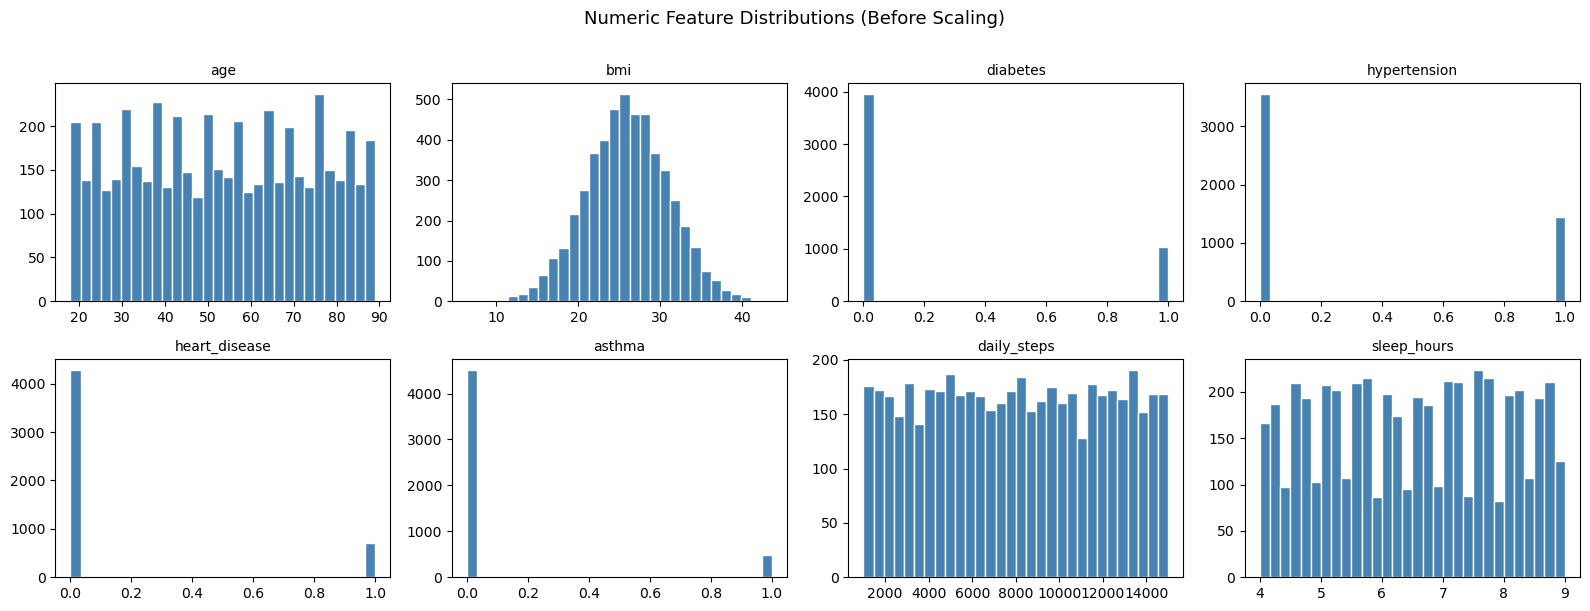

In [17]:
# Visualize spread before scaling
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns[:8]  # first 8 for readability

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    axes[i].hist(X[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
plt.suptitle('Numeric Feature Distributions (Before Scaling)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Standardize Numeric Features

We apply **StandardScaler** (zero mean, unit variance) to all numeric features.  
Dummy/boolean columns are excluded from scaling since they are already on a 0/1 scale.

In [18]:
# Separate continuous numerics from binary dummies
bool_cols = [c for c in X.columns if set(X[c].unique()).issubset({0, 1, True, False})]
scale_cols = [c for c in X.columns if c not in bool_cols]

print(f'Columns to scale ({len(scale_cols)}):  {scale_cols}')
print(f'Binary/dummy cols ({len(bool_cols)}):  {bool_cols}')

Columns to scale (10):  ['age', 'bmi', 'daily_steps', 'sleep_hours', 'stress_level', 'doctor_visits_per_year', 'hospital_admissions', 'medication_count', 'insurance_coverage_pct', 'previous_year_cost']
Binary/dummy cols (12):  ['diabetes', 'hypertension', 'heart_disease', 'asthma', 'gender_Male', 'smoker_Yes', 'physical_activity_level_Low', 'physical_activity_level_Medium', 'insurance_type_None', 'insurance_type_Private', 'city_type_Semi-Urban', 'city_type_Urban']


In [19]:
# Fit and apply StandardScaler to continuous numeric columns
scaler = preprocessing.StandardScaler()

X_scaled_numeric = scaler.fit_transform(X[scale_cols])
X_scaled_numeric = pd.DataFrame(X_scaled_numeric, columns=scale_cols, index=X.index)

# Recombine with binary columns (unchanged)
X_scaled = pd.concat([X_scaled_numeric, X[bool_cols]], axis=1)

print(f'Scaled feature set shape: {X_scaled.shape}')
X_scaled.describe().round(3)

Scaled feature set shape: (5000, 22)


,age,bmi,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_coverage_pct,previous_year_cost,diabetes,hypertension,heart_disease,asthma
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.208,0.288,0.142,0.096
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.406,0.453,0.349,0.295
min,-1.710,-3.878,-1.725,-1.724,-1.547,-2.005,-1.023,-1.531,-1.833,-1.733,0.000,0.000,0.000,0.000
25%,-0.838,-0.668,-0.851,-0.893,-0.856,-0.513,-1.023,-1.094,-0.157,-0.872,0.000,0.000,0.000,0.000
50%,-0.014,-0.014,-0.001,0.008,-0.164,-0.015,-0.001,-0.222,0.413,0.006,0.000,0.000,0.000,0.000
75%,0.857,0.680,0.873,0.840,0.873,0.482,1.021,1.087,0.666,0.851,0.000,1.000,0.000,0.000
max,1.729,3.494,1.729,1.740,1.565,4.959,5.109,1.523,1.140,1.733,1.000,1.000,1.000,1.000


In [20]:
# Verify: scaled numeric columns should have mean ≈ 0 and std ≈ 1
check = X_scaled[scale_cols].agg(['mean', 'std']).T
check.columns = ['Mean (should be ~0)', 'Std (should be ~1)']
check.round(4)

,Mean (should be ~0),Std (should be ~1)
age,0.0,1.0001
bmi,0.0,1.0001
daily_steps,-0.0,1.0001
sleep_hours,0.0,1.0001
stress_level,0.0,1.0001
doctor_visits_per_year,0.0,1.0001
hospital_admissions,0.0,1.0001
medication_count,0.0,1.0001
insurance_coverage_pct,-0.0,1.0001
previous_year_cost,-0.0,1.0001


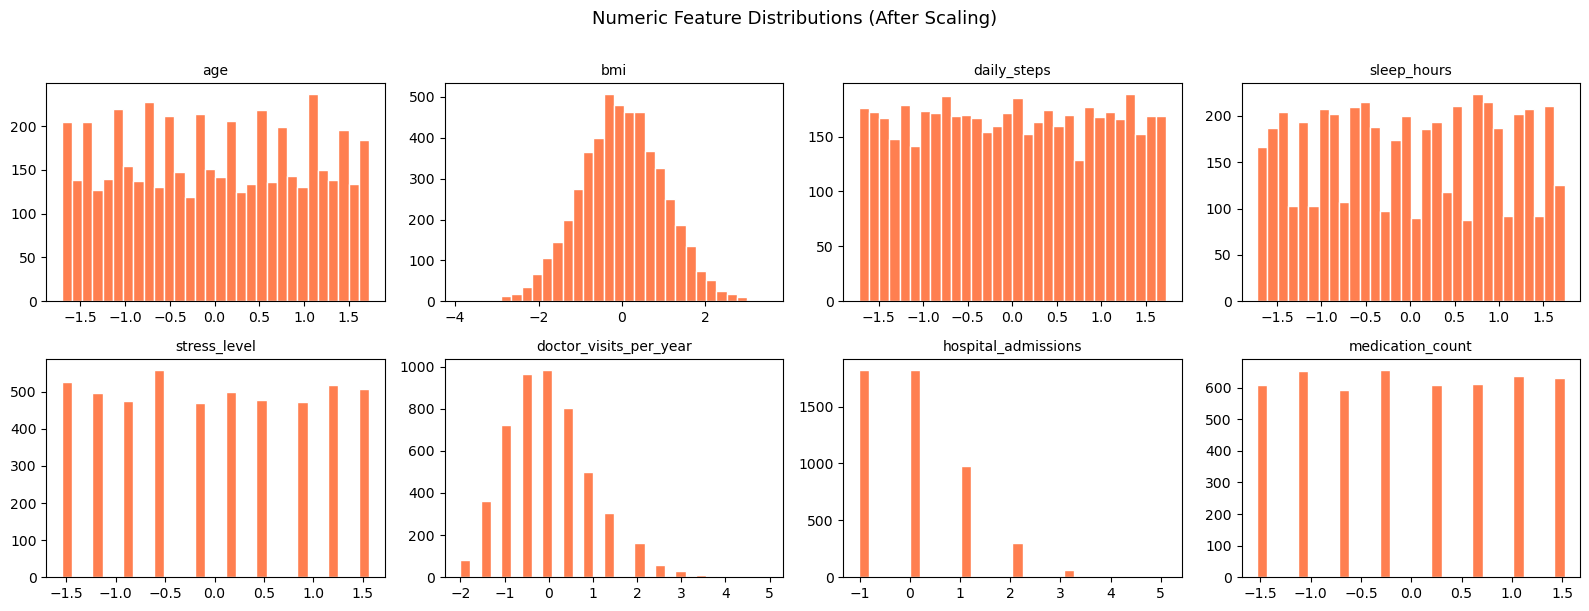

In [21]:
# Visualize distributions after scaling
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
for i, col in enumerate(scale_cols[:8]):
    axes[i].hist(X_scaled[col], bins=30, color='coral', edgecolor='white')
    axes[i].set_title(col, fontsize=10)
plt.suptitle('Numeric Feature Distributions (After Scaling)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Train / Test Split

We use an **80/20 split** with a fixed random seed for reproducibility.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42
)

print(f'Training set:   X={X_train.shape}, y={y_train.shape}')
print(f'Test set:       X={X_test.shape},  y={y_test.shape}')
print(f'\nTrain %: {len(X_train)/len(X_scaled)*100:.1f}%  |  Test %: {len(X_test)/len(X_scaled)*100:.1f}%')

Training set:   X=(4000, 22), y=(4000,)
Test set:       X=(1000, 22),  y=(1000,)

Train %: 80.0%  |  Test %: 20.0%


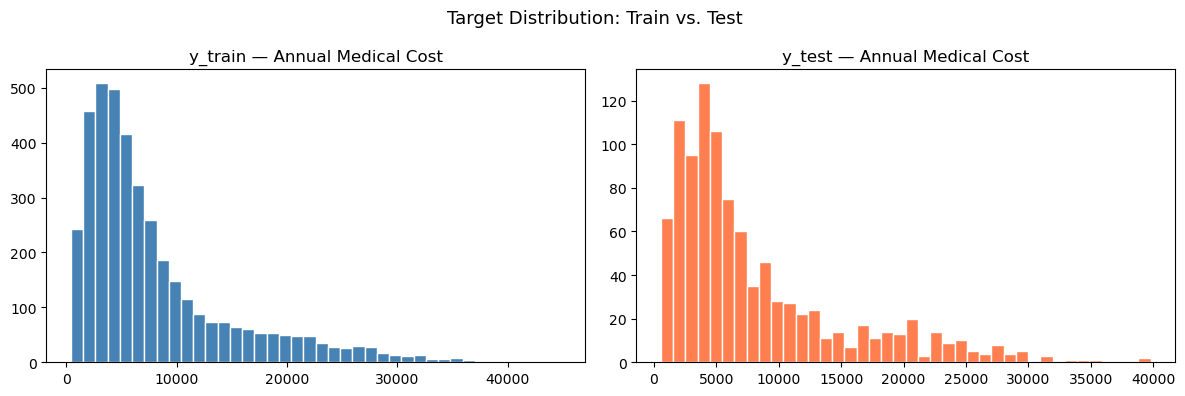

Train mean: $8,057.09  |  Test mean: $8,016.08


In [23]:
# Confirm target distribution is similar between train and test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('y_train — Annual Medical Cost')
axes[1].hist(y_test, bins=40, color='coral', edgecolor='white')
axes[1].set_title('y_test — Annual Medical Cost')
plt.suptitle('Target Distribution: Train vs. Test', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Train mean: ${y_train.mean():,.2f}  |  Test mean: ${y_test.mean():,.2f}')

---
## 9. Save Preprocessed Data

Save the fully preprocessed feature matrix and target for use in the modeling step.

In [25]:
# Save full preprocessed dataset
preprocessed = X_scaled.copy()
preprocessed[TARGET] = y.values
preprocessed.to_csv('medical_cost_preprocessed.csv', index=False)

# Save individual splits
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print('Saved:')
print('  medical_cost_preprocessed.csv  — full preprocessed dataset')
print('  X_train.csv / X_test.csv       — feature splits')
print('  y_train.csv / y_test.csv       — target splits')

Saved:
  medical_cost_preprocessed.csv  — full preprocessed dataset
  X_train.csv / X_test.csv       — feature splits
  y_train.csv / y_test.csv       — target splits


---
## 10. Summary

| Step | Action | Detail |
|---|---|---|
| **Missing values** | Imputed | `insurance_type` → filled with 0 |
| **Dummy encoding** | `pd.get_dummies(drop_first=True)` | 5 categorical columns → 7 binary dummies |
| **Feature scaling** | `StandardScaler` | Applied to 14 continuous numeric columns |
| **Binary columns** | Left as-is | 7 dummy columns already on 0/1 scale |
| **Train/test split** | 80/20 | 4,000 train rows / 1,000 test rows, `random_state=42` |
| **Target** | `annual_medical_cost` | Not scaled (regression target) |

The dataset is now ready for the **modeling step** .